# Clasificación de latidos de ECG con Deep Learning

**Proyecto Final — Deep Learning para Series Temporales**

## 1. Introducción

Este proyecto aborda la **clasificación supervisada de series temporales** aplicada a electrocardiogramas (ECG). Usaremos el dataset **MIT-BIH Arrhythmia** del paquete  ECG Heartbeat Categorization Dataset de Kaggle, donde cada muestra es un latido cardíaco individual representado como una serie temporal de 187 puntos (ya remuestreada y normalizada al rango [0, 1]) y etiquetada en una de 5 clases:

| Etiqueta | Clase | Descripción |
|----------|-------|-------------|
| 0 | N | Latido normal |
| 1 | S | Supraventricular |
| 2 | V | Ventricular |
| 3 | F | Fusión |
| 4 | Q | Desconocido / no clasificable |




### 2. Configuración del notebook

In [1]:
# Librerías estándar
import os
import random
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

# Pytorch
import torch

# Configuración Drive
from google.colab import drive
drive.mount('/content/drive')


# Reproducibilidad: fijamos semillas
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Comprobar GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Ruta a los datos
DATA_DIR = "/content/drive/MyDrive/SeriesTemp/data"

print("Setup completado")
print(f"Pandas {pd.__version__}, NumPy {np.__version__}, PyTorch {torch.__version__}")

Mounted at /content/drive
Device: cuda
Setup completado
Pandas 2.2.2, NumPy 2.0.2, PyTorch 2.10.0+cu128


## 3. Carga de datos

In [2]:
# Cargamos train y test
train_df = pd.read_csv(os.path.join(DATA_DIR, "mitbih_train.csv"), header=None)
test_df  = pd.read_csv(os.path.join(DATA_DIR, "mitbih_test.csv"),  header=None)

print(f"Train shape: {train_df.shape}")
print(f"Test  shape: {test_df.shape}")

Train shape: (87554, 188)
Test  shape: (21892, 188)


In [3]:
# Mostrar las primeras filas del train
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Separamos la señal (X) de la etiqueta (y)
# Las columnas 0-186 son la serie temporal (187 puntos)
# La columna 187 es la clase

X_train = train_df.iloc[:, :-1].values   # shape (n_train, 187)
y_train = train_df.iloc[:, -1].values.astype(int)

X_test  = test_df.iloc[:, :-1].values    # shape (n_test, 187)
y_test  = test_df.iloc[:, -1].values.astype(int)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")
print(f"\nTipo X_train: {X_train.dtype}")
print(f"Tipo y_train: {y_train.dtype}")
print(f"\nValores únicos de y_train: {np.unique(y_train)}")
print(f"Valores únicos de y_test : {np.unique(y_test)}")
print(f"\nRango de X_train: [{X_train.min():.3f}, {X_train.max():.3f}]")

X_train: (87554, 187), y_train: (87554,)
X_test : (21892, 187), y_test : (21892,)

Tipo X_train: float64
Tipo y_train: int64

Valores únicos de y_train: [0 1 2 3 4]
Valores únicos de y_test : [0 1 2 3 4]

Rango de X_train: [0.000, 1.000]


Definimos un mapeo de etiquetas a nombres legibles para usar en gráficas y reports.

In [5]:
# Mapeo etiqueta -> nombre legible
CLASS_NAMES = {
    0: "N (Normal)",
    1: "S (Supraventricular)",
    2: "V (Ventricular)",
    3: "F (Fusión)",
    4: "Q (Desconocido)",
}

# Lista ordenada para usar en gráficas
class_labels = [CLASS_NAMES[i] for i in range(5)]
print(class_labels)

['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusión)', 'Q (Desconocido)']


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribución de clases
Ánalisis de la distribución de clases para ver si hay datos desbalanmceados o no.

In [6]:
# Conteo y porcentaje por clase en train y test
def class_distribution(y, name):
    counts = pd.Series(y).value_counts().sort_index()
    pct = (counts / len(y) * 100).round(2)
    df = pd.DataFrame({
        "clase": [CLASS_NAMES[i] for i in counts.index],
        f"n_{name}": counts.values,
        f"%_{name}": pct.values,
    })
    return df

dist_train = class_distribution(y_train, "train")
dist_test  = class_distribution(y_test,  "test")

dist = dist_train.merge(dist_test.drop(columns="clase"),
                        left_index=True, right_index=True)
dist

,clase,n_train,%_train,n_test,%_test
0,N (Normal),72471,82.77,18118,82.76
1,S (Supraventricular),2223,2.54,556,2.54
2,V (Ventricular),5788,6.61,1448,6.61
3,F (Fusión),641,0.73,162,0.74
4,Q (Desconocido),6431,7.35,1608,7.35


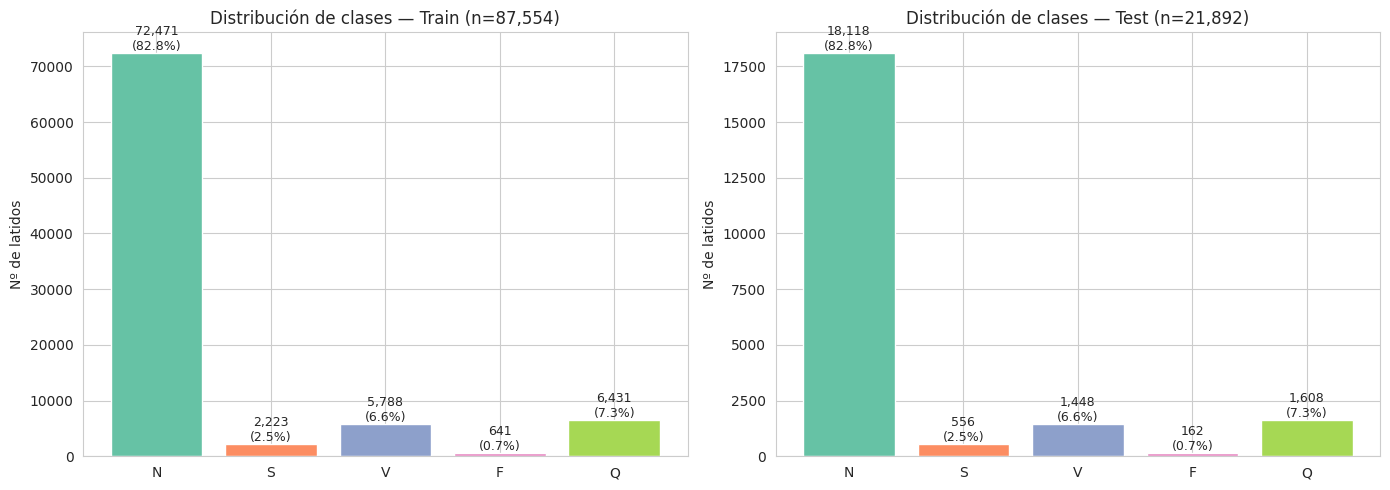

In [7]:
# Visualización de la distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y, name) in zip(axes, [(y_train, "Train"), (y_test, "Test")]):
    counts = pd.Series(y).value_counts().sort_index()
    bars = ax.bar(range(5), counts.values,
                  color=sns.color_palette("Set2", 5))
    ax.set_xticks(range(5))
    ax.set_xticklabels([CLASS_NAMES[i].split(" ")[0] for i in range(5)])
    ax.set_title(f"Distribución de clases — {name} (n={len(y):,})")
    ax.set_ylabel("Nº de latidos")

    # Añadir el porcentaje encima de cada barra
    for bar, count in zip(bars, counts.values):
        pct = count / len(y) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

El dataset presenta un fuerte desbalance: la clase N representa aproximadamente el 83% de las muestras, mientras que la clase F apenas supone un 0.7%. La distribución es prácticamente idéntica en train y test, lo que permite suponer que el split original ya viene estratificado.

Este desbalance supone que la accuracy como métrica principal puede ser engañosa ya que un modelo que prediga siempre N alcazaria resultados muy buenos sin aprender nada. En este caso usaremos accuracy junto con F1 (weighted y macro) para tener una visión más fiable, prestando especial atención al rendimiento en las clases minoritarias.

Además el split para la validación de los modelos entrenados debe hacerse de forma estratificada para mantener las proporciones originales de las clases.

Dada la distribución de las clases, descartamos *undersampling* de la clase N (perderíamos demasiada información) y *oversampling* sintético tipo SMOTE (generar latidos interpolados) puede producir señales no plausibles cardíacamente. Optamos por ponderar las clases en la función de pérdida (`class_weight="balanced"`), de forma que los errores en clases minoritarias penalicen más.

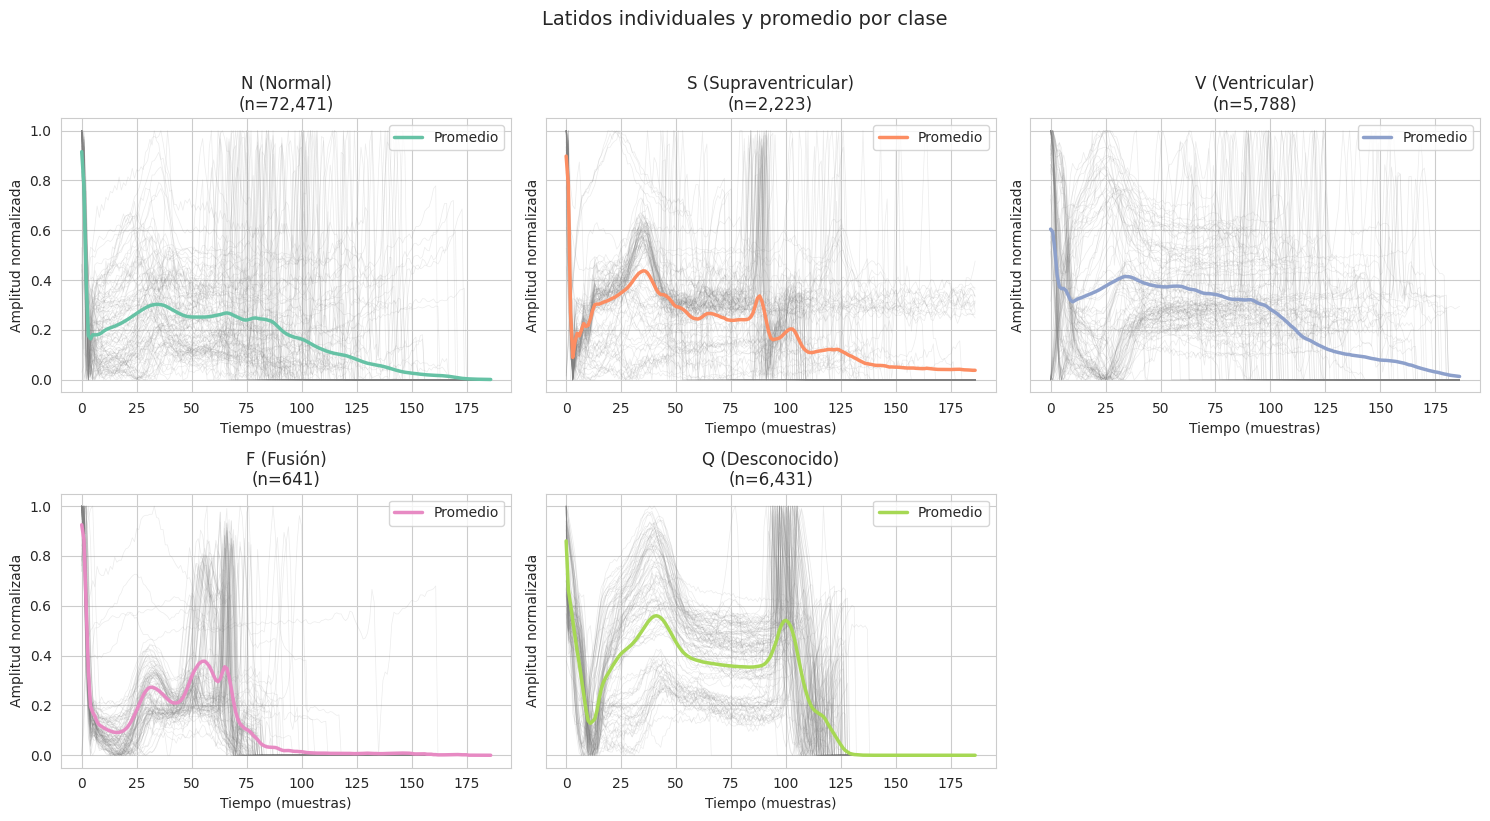

In [8]:
# Para cada clase, dibujamos varios latidos individuales (en gris) + el latido medio (en color)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

N_SAMPLES_PER_CLASS = 100  # cuántos latidos individuales superponer

palette = sns.color_palette("Set2", 5)

for c in range(5):
    ax = axes[c]
    # Índices de las muestras de la clase c en train
    idx_class = np.where(y_train == c)[0]
    # Seleccionar aleatoriamente N_SAMPLES_PER_CLASS
    idx_sample = np.random.choice(idx_class,
                                  size=min(N_SAMPLES_PER_CLASS, len(idx_class)),
                                  replace=False)

    # Dibujar las muestras individuales en gris semi-transparente
    for i in idx_sample:
        ax.plot(X_train[i], color="gray", alpha=0.15, linewidth=0.5)

    # Dibujar el latido promedio de la clase
    mean_signal = X_train[idx_class].mean(axis=0)
    ax.plot(mean_signal, color=palette[c], linewidth=2.5, label="Promedio")

    ax.set_title(f"{CLASS_NAMES[c]}\n(n={len(idx_class):,})")
    ax.set_xlabel("Tiempo (muestras)")
    ax.set_ylabel("Amplitud normalizada")
    ax.legend(loc="upper right")

# Ocultar el último subplot vacío (porque tenemos 5 clases en una rejilla 2x3)
axes[5].axis("off")

plt.suptitle("Latidos individuales y promedio por clase", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Cada clase tiene una tipología de señal diferente pero también se puede ver la variabilidad que hay en cada uno de los tipos (líneas grises).

- N tiene un único pico R prominente al inicio y luego cae suavemente — morfología "limpia"
- S es muy parecida a N pero con un segundo pico secundario aparente alrededor de la posición 30 y otro en el 100.
- V tiene una caída más marcada y patrones más caóticos en los individuales.
- F muestra dos picos claros (~30 y ~50) y termina antes (consistente con el padding que vimos).
- Q es la que más destaca: tres picos pronunciados en posiciones muy fijas (~10 ~40, y ~100) y la menor variabilidad.

Dentro de cada una de las clases, N, S y V presentan más variabilidad, en cambio que F o Q son más homogeneos.

Como las clases se distinguen por la forma de la señal y la posición de los picos, son patrones que pueden capturar bien las redes  1D, que aprenden filtros locales sensibles a estas formas.

In [9]:
def real_length(signal, eps=1e-6):
    """Devuelve la posición del último valor no nulo + 1."""
    nonzero = np.where(signal > eps)[0]
    return nonzero[-1] + 1 if len(nonzero) > 0 else 0

# Calcular longitud real de cada latido en train
real_lengths = np.array([real_length(s) for s in X_train])

# Estadísticas globales
print("Estadísticas de la longitud real de los latidos (train):")
print(f"  Mín:    {real_lengths.min()}")
print(f"  Máx:    {real_lengths.max()}")
print(f"  Media:  {real_lengths.mean():.1f}")
print(f"  Mediana:{np.median(real_lengths):.1f}")

Estadísticas de la longitud real de los latidos (train):
  Mín:    17
  Máx:    187
  Media:  111.7
  Mediana:109.0


Es importante tener en cuenta que algunas series tienen un padding añadido para adecuarse a la longitud de 187 a pesar de ser señales más cortas. Si vemos la distribución segmentada por categorias se ve de la siguiente manera.

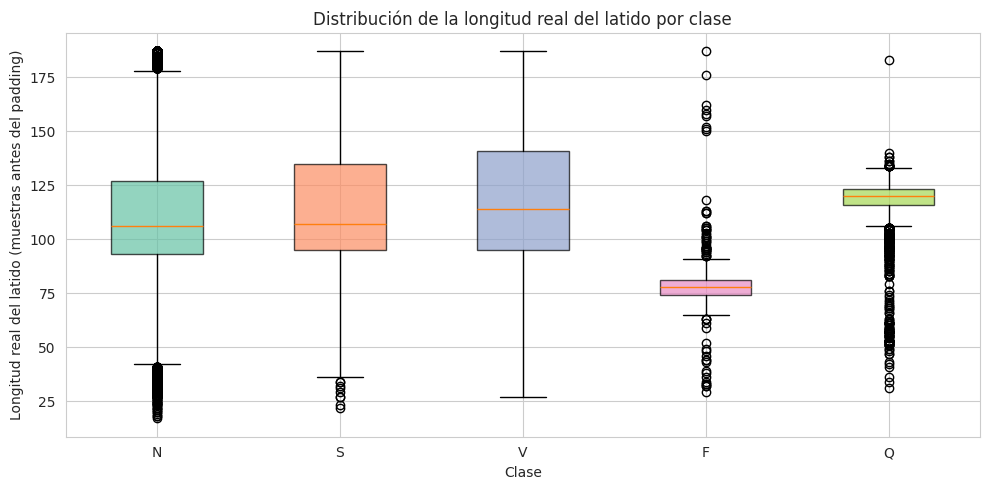

In [10]:
# Distribución de la longitud real por clase
fig, ax = plt.subplots(figsize=(10, 5))

data_box = [real_lengths[y_train == c] for c in range(5)]
bp = ax.boxplot(data_box,
                tick_labels=[CLASS_NAMES[i].split(" ")[0] for i in range(5)],
                patch_artist=True)

for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Longitud real del latido (muestras antes del padding)")
ax.set_xlabel("Clase")
ax.set_title("Distribución de la longitud real del latido por clase")
plt.tight_layout()
plt.show()

Podemos observar que la categorias N, S y V muestran distribuciones de longitud muy similares y tambien latidos más heterogeneos tal y como se puede ver en la representación de los latidos. Sin embargo la categoria F tiene latidos más cortos y homogeneos, algo a tener en cuenta porque los modelos podría detectar como praton el padding en lugar de la morfologia de la señal. La clase Q presenta una mediana alta y muchos outliers cortos, sugiriendo heterogeneidad interna (es la clase "cajón de sastre").

## 5. Preprocesado y preparación

### 5.1 Split de validación

El dataset trae solo `train` y `test`. Como vamos a iterar entre varios modelos y necesitamos tomar decisiones (early stopping, comparar arquitecturas, etc.), **reservaremos un 15% del train como validación**. El test queda intacto hasta el final, cuando evaluemos el modelo elegido.

Hacemos el split **estratificado** para que la proporción de clases se mantenga, algo importante dado el fuerte desbalance.

In [11]:
# Split estratificado del train original en train (85%) + validación (15%)
X_train_full, y_train_full = X_train, y_train  # guardo referencia del train completo

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    stratify=y_train_full,
    random_state=SEED,
)

print(f"Train      : {X_tr.shape}, y={y_tr.shape}")
print(f"Validation : {X_val.shape}, y={y_val.shape}")
print(f"Test       : {X_test.shape}, y={y_test.shape}")

# Comprobar que la proporción de clases se mantiene
print("\nProporción de clases (en %):")
prop_df = pd.DataFrame({
    "train_full": pd.Series(y_train_full).value_counts(normalize=True).sort_index() * 100,
    "train":      pd.Series(y_tr).value_counts(normalize=True).sort_index() * 100,
    "val":        pd.Series(y_val).value_counts(normalize=True).sort_index() * 100,
    "test":       pd.Series(y_test).value_counts(normalize=True).sort_index() * 100,
}).round(2)
prop_df.index = [CLASS_NAMES[i] for i in prop_df.index]
prop_df

Train      : (74420, 187), y=(74420,)
Validation : (13134, 187), y=(13134,)
Test       : (21892, 187), y=(21892,)

Proporción de clases (en %):


,train_full,train,val,test
N (Normal),82.77,82.77,82.77,82.76
S (Supraventricular),2.54,2.54,2.54,2.54
V (Ventricular),6.61,6.61,6.61,6.61
F (Fusión),0.73,0.73,0.73,0.74
Q (Desconocido),7.35,7.34,7.35,7.35


### 5.2 Función de evaluación reutilizable

Dado que vamos a comparar varios modelos (baseline trivial, ML clásico, varios DL), creamos una función estándar que reciba `y_true` e `y_pred` y devuelva todas las métricas relevantes en un formato uniforme. Esto facilita la comparación final.

In [12]:
from sklearn.metrics import confusion_matrix

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Modelo"):
    """
    Evalúa un modelo de clasificación multi-clase.
    Si se pasan probabilidades, también calcula ROC-AUC.
    """
    acc          = accuracy_score(y_true, y_pred)
    f1_weighted  = f1_score(y_true, y_pred, average="weighted")
    f1_macro  = f1_score(y_true, y_pred, average="macro")
    f1_per_class = f1_score(y_true, y_pred, average=None)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  F1-weighted     : {f1_weighted:.4f}")
    print(f"  F1-macro     : {f1_macro:.4f}")

    result = {
        "model": model_name,
        "accuracy": acc,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        "f1_per_class": f1_per_class,
        "y_pred": y_pred,
    }

    if y_proba is not None:
        auc_weighted = roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted")
        print(f"  AUC weighted    : {auc_weighted:.4f}")
        result["auc_weighted"] = auc_weighted

    print(classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values())))


    return result

def plot_confusion_matrix(y_true, y_pred, model_name="Modelo", normalize=True):
    """Dibuja la matriz de confusión (normalizada por filas o no)."""
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        title = f"Matriz de confusión normalizada — {model_name}"
    else:
        fmt = "d"
        title = f"Matriz de confusión — {model_name}"

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=[CLASS_NAMES[i].split(" ")[0] for i in range(5)],
                yticklabels=[CLASS_NAMES[i].split(" ")[0] for i in range(5)],
                ax=ax, cbar=True)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

### 5.3 Pesos por clase para el desbalance

Como ya se ha mencionado anteriormente, el dataset está muy desbalanceado con alrededor del 83% de muestras clasificadas como normales. Para evitar el sesgo  de los modelos a la clase mayoritaria se va a asignar un peso inverso a la frecuencia, de forma que las clases minoritarias contribuyan más a la función de pérdida. Se calculan de la siguiente manera:

`w_c = n_total / (n_clases × n_c)`

- Donde `n_c` es el número de muestra de la clase.


In [13]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(5),
    y=y_tr
)

print("Class weights calculados sobre el train:")
for c, w in enumerate(class_weights):
    print(f"  {CLASS_NAMES[c]:<25}: peso = {w:.3f}")

print(f"\nRatio mínimo/máximo de pesos: {class_weights.min():.3f} / {class_weights.max():.3f}")
print(f"Esto significa que un error en la clase F va a pesar {class_weights[3]/class_weights[0]:.1f} x"
      f" más que un error en la clase N.")

Class weights calculados sobre el train:
  N (Normal)               : peso = 0.242
  S (Supraventricular)     : peso = 7.879
  V (Ventricular)          : peso = 3.025
  F (Fusión)               : peso = 27.310
  Q (Desconocido)          : peso = 2.723

Ratio mínimo/máximo de pesos: 0.242 / 27.310
Esto significa que un error en la clase F va a pesar 113.0 x más que un error en la clase N.


## 6. Baselines

Los baselines permiten establecer cual es el suelo del rendimiento. Es decir, cual es el mímino que todo modelo avanzado debería poder superar. En este caso se han utilizado dos baselines uno trivial (*DummyClassifier*) que permite mostrar el límite inferior y además demostrar que el *accuracy* engaña en este dataset. El otro modelo de Machine Learning (ML) clásico (*RandomForest*) que sirve para comparar los modelos de DL desarrollado, si no supera al modelo de ML no aporta valor real.

### 6.1 Baseline trivial — clasificador de mayoría
Como predice siempre N (la clase mayoritaria), su accuracy igualará la frecuencia de N (~83%), pero su F1-macro será muy bajo porque ignora completamente las cuatro clases minoritarias. Esto refuerza la elección de F1 como métrica principal.



  Baseline trivial (clase mayoritaria)
  Accuracy        : 0.8276
  F1-weighted     : 0.7495
  F1-macro     : 0.1811
                      precision    recall  f1-score   support

          N (Normal)       0.83      1.00      0.91     18118
S (Supraventricular)       0.00      0.00      0.00       556
     V (Ventricular)       0.00      0.00      0.00      1448
          F (Fusión)       0.00      0.00      0.00       162
     Q (Desconocido)       0.00      0.00      0.00      1608

            accuracy                           0.83     21892
           macro avg       0.17      0.20      0.18     21892
        weighted avg       0.68      0.83      0.75     21892



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


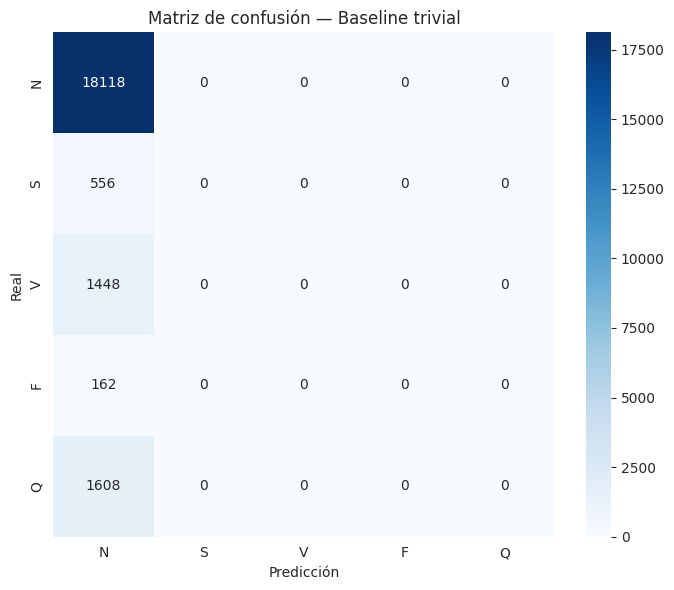

In [14]:
from sklearn.dummy import DummyClassifier

# Modelo trivial
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_tr, y_tr)

# Predicciones sobre el test
y_pred_dummy = dummy.predict(X_test)

# Evaluamos con la función que definimos antes
results = {}  # diccionario para acumular resultados de todos los modelos
results["Baseline trivial"] = evaluate_model(
    y_test,
    y_pred_dummy,
    model_name="Baseline trivial (clase mayoritaria)"
)
# Matriz de confusión
plot_confusion_matrix(y_test, y_pred_dummy, "Baseline trivial", normalize=False)

El comportamiento es el esperado: al asignar todas las muestras a N, el clasificador obtiene cero recall en las clases minoritarias y un *accuracy* cercano a la frecuencia de N. EEl F1-macro de ~0.18 refleja que el modelo no captura ninguna de las clases minoritarias. La matriz lo confirma visualmente.

Este baseline valida la elección del F1 como métrica principal.

### 6.2 Baseline ML clásico — Random Forest (RF)

Random forest es un modelo robusto que no necesita ajuste fino y además permite manejar el desbalanceo de clases con `class_weight`. El RandomForest, al tratar cada punto como una feature independiente, no aprovecha la estructura local de la señal (ej. la forma de un pico).

Este baseline permite fijar el mínimo sobre el que deben mejorar los modelos de DL.

Entrenando Random Forest... (puede tardar 1-3 min)
Entrenamiento terminado en 145.1s

--- Resultados en VALIDACIÓN ---

  Random Forest (val)
  Accuracy        : 0.9746
  F1-weighted     : 0.9737
  F1-macro     : 0.8670
  AUC weighted    : 0.9949
                      precision    recall  f1-score   support

          N (Normal)       0.98      0.99      0.99     10871
S (Supraventricular)       0.93      0.64      0.76       334
     V (Ventricular)       0.98      0.89      0.93       868
          F (Fusión)       0.64      0.73      0.68        96
     Q (Desconocido)       1.00      0.96      0.98       965

            accuracy                           0.97     13134
           macro avg       0.90      0.84      0.87     13134
        weighted avg       0.97      0.97      0.97     13134


--- Resultados en TEST ---

  Random Forest (test)
  Accuracy        : 0.9713
  F1-weighted     : 0.9701
  F1-macro     : 0.8542
  AUC weighted    : 0.9936
                      precision    

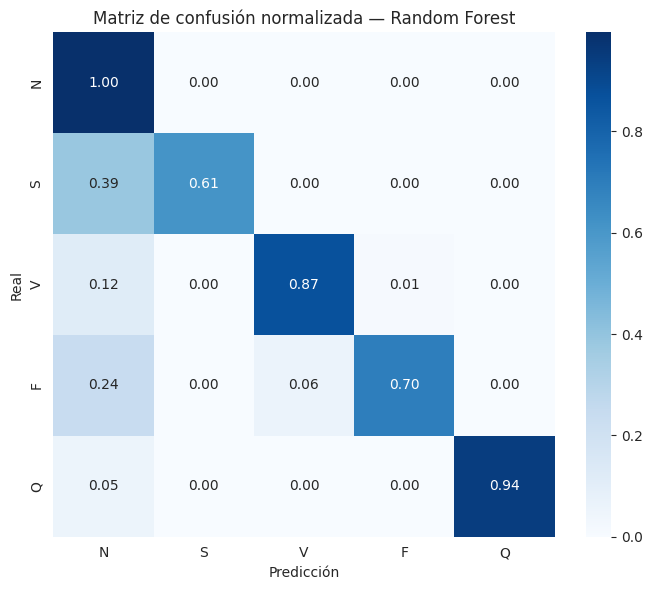

In [15]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Entrenando Random Forest... (puede tardar 1-3 min)")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=200,         # 200 árboles, suficientes para un baseline
    max_depth=20,             # limitamos profundidad para acelerar y evitar overfitting
    class_weight="balanced",  # ponderación inversa a la frecuencia (igual que en DL)
    n_jobs=-1,                # usar todos los cores disponibles
    random_state=SEED,
)
rf.fit(X_tr, y_tr)

print(f"Entrenamiento terminado en {time.time()-t0:.1f}s")

# Predicciones sobre validación y test
y_pred_rf_val  = rf.predict(X_val)
y_proba_rf_val = rf.predict_proba(X_val)

y_pred_rf_test = rf.predict(X_test)
y_proba_rf_test = rf.predict_proba(X_test)

# Evaluación sobre validación (para tener referencia)
print("\n--- Resultados en VALIDACIÓN ---")
_ = evaluate_model(y_val, y_pred_rf_val, y_proba=y_proba_rf_val, model_name="Random Forest (val)")

# Evaluación sobre test (la que cuenta)
print("\n--- Resultados en TEST ---")
results["Random Forest"] = evaluate_model(y_test, y_pred_rf_test, y_proba=y_proba_rf_test, model_name="Random Forest (test)")

# Matriz de confusión sobre test
plot_confusion_matrix(y_test, y_pred_rf_test, "Random Forest", normalize=True)

El RandomForest establece la vara competitiva (F1-weighted = 0.9701, F1-macro = 0.8542 en test). Para superarlo significativamente, especialmente en las clases minoritarias S y F, recurrimos a Deep Learning.

## 7. Modelos de Deep Learning

A diferencia del RF, las CNNs 1D sí que son capaces de capturar la estructura temporal local de la señal mediante filtros convolucionales. Esto permite capturar la forma temporal y la posición los picos que se distigían en la sección de exploración de los datos (*4. EDA*).

El plan es probar 4 arquitecturas diferentes en orden de complejidad creciente:
- CNN 1D simple sin class weights para visualizar el efecto puro del desbalance
- CNN 1D simple con class weights
- ResNet 1D (conexiones residuales)
- InceptionTime (módulos en paralelo con kernels de distintos tamaños)



In [16]:
# Comprobamos GPU
!nvidia-smi

Sun May  3 09:23:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

 ### 7.2 Conversión a tensores y DataLoaders

In [17]:
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader
import random
import fastai
from fastai.basics import DataLoaders, Learner, accuracy, Adam
print(f"fastai version: {fastai.__version__}")

fastai version: 2.8.7


In [18]:
# Convierto el array de NumPy a tensor
X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

# Convertir etiquetas a tensores
y_tr_tensor = torch.tensor(y_tr, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

for name, X, y in [("Train", X_tr_tensor, y_tr_tensor),
                   ("Val",   X_val_tensor, y_val_tensor),
                   ("Test",  X_test_tensor, y_test_tensor)]:
    print(f"{name:5}: X={X.shape}, y={y.shape}")

Train: X=torch.Size([74420, 1, 187]), y=torch.Size([74420])
Val  : X=torch.Size([13134, 1, 187]), y=torch.Size([13134])
Test : X=torch.Size([21892, 1, 187]), y=torch.Size([21892])


In [19]:
BATCH_SIZE = 256

train_ds = TensorDataset(X_tr_tensor, y_tr_tensor)
val_ds   = TensorDataset(X_val_tensor, y_val_tensor)

# Construir el `DataLoaders` de fastai, que empaqueta el DataLoader de train y validación.
dls = DataLoaders.from_dsets(train_ds, val_ds, bs=BATCH_SIZE).to(device)

xb, yb = dls.one_batch()
print(f"X batch: {xb.shape}, dtype={xb.dtype}, device={xb.device}")
print(f"y batch: {yb.shape}, dtype={yb.dtype}, device={yb.device}")

X batch: torch.Size([256, 1, 187]), dtype=torch.float32, device=cuda:0
y batch: torch.Size([256]), dtype=torch.int64, device=cuda:0


In [20]:
# Convertir a tensor los clas weights para poder
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"class_weights (NumPy): {class_weights}, type: {type(class_weights).__name__}")
print(f"class_weights_tensor:  {class_weights_tensor}, device: {class_weights_tensor.device}")

class_weights (NumPy): [ 0.24162338  7.87930122  3.02520325 27.31009174  2.723015  ], type: ndarray
class_weights_tensor:  tensor([ 0.2416,  7.8793,  3.0252, 27.3101,  2.7230], device='cuda:0'), device: cuda:0


fastai trae `accuracy` por defecto pero no F1, así que lo importamos de
`fastai.metrics`. Configuramos dos versiones (macro y weighted) con
nombres explícitos para que aparezcan claramente en la tabla de progreso
durante el `fit`. La métrica principal sigue siendo F1-weighted, alineada
con la elección que justificamos en la sección 4.

In [21]:
from fastai.metrics import F1Score, accuracy

f1_macro = F1Score(average='macro')
f1_macro.name = 'f1_macro'

f1_weighted = F1Score(average='weighted')
f1_weighted.name = 'f1_weighted'

metrics_list = [accuracy, f1_macro, f1_weighted]

 ### 7.3 Funciones reutilizables

In [22]:
def evaluate_learner(learn, X_test_tensor, y_test_tensor, model_name="Modelo"):
    """
    Evalúa un Learner de fastai sobre el test set y reutiliza evaluate_model.
    """
    # 1. Crear test Dataset y  dataloader
    test_ds = TensorDataset(X_test_tensor, y_test_tensor)
    test_dl = learn.dls.test_dl(test_ds, with_labels=True)

    # 2. Obtener predicciones (probas) y targets
    raw_preds, targets = learn.get_preds(dl=test_dl)

    # 3. Aplicar softmax para obtener probabilidades reales
    probas = torch.softmax(raw_preds, dim=1)

    # 3. Convertir a NumPy
    y_proba = probas.cpu().numpy()
    y_true  = targets.cpu().numpy()
    y_pred  = y_proba.argmax(axis=1)

    # 4. Reutilizar evaluate_model
    result = evaluate_model(y_true, y_pred, y_proba=y_proba, model_name=model_name)

    # 5. Matriz de confusión
    plot_confusion_matrix(y_true, y_pred, model_name=model_name, normalize=True)

    return result

### 7.4 MiniROCKET


In [23]:
!pip install aeon --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 74.9 MB/s eta 0:00:00


In [24]:
# importar librerias para esta sección
import aeon
from aeon.transformations.collection.convolution_based import MiniRocket
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print(f"aeon version: {aeon.__version__}")
print("MiniRocket importado correctamente")

aeon version: 1.4.0
MiniRocket importado correctamente


In [25]:
# Para MiniRocket transformo los datos a 3 dimensiones de numpy (74420, 1 187)
# MiniRocket no acepta el formato 2D

X_tr_3d = np.expand_dims(X_tr, axis=1)
X_val_3d = np.expand_dims(X_val, axis=1)
X_test_3d = np.expand_dims(X_test, axis=1)

print(f"X_tr_3d: {X_tr_3d.shape}")
print(f"X_val_3d: {X_val_3d.shape}")
print(f"X_test_3d: {X_test_3d.shape}")


X_tr_3d: (74420, 1, 187)
X_val_3d: (13134, 1, 187)
X_test_3d: (21892, 1, 187)


In [26]:
# Uso Logistic Regression en vez de Ridge, que es lo que recomienda
# el paper original, para poder predecir probabilidades.

#miniRocket = Pipeline([
#    ("minirocket", MiniRocket(n_jobs=-1)),
#   ("scaler", StandardScaler()),
#    ("classifier", LogisticRegressionCV(Cs=10, max_iter=2000, n_jobs=-1, class_weight="balanced")),
#])

from sklearn.linear_model import RidgeClassifier
from sklearn.calibration import CalibratedClassifierCV

# el pipeline comentado tarda demasiado en ejeciutarse y no es viable para los limite de colab.
# utilizamos RidgeClassifier con probabilidades calibradas porque Ridge solo no
# da probabilidades.
minirocket = Pipeline([
    ("minirocket", MiniRocket(n_kernels=2500, n_jobs=-1)),
    ("classifier", CalibratedClassifierCV(
        RidgeClassifier(class_weight="balanced"),
        cv=3,
        method="sigmoid"
    )),
])


In [27]:
from sklearn.model_selection import train_test_split

# Subset estratificado de 5000 muestras
X_subset, _, y_subset, _ = train_test_split(
    X_tr_3d, y_tr, train_size=5000, stratify=y_tr, random_state=SEED
)

import time
t0 = time.time()
minirocket.fit(X_subset, y_subset)
print(f"Entrenamiento subset terminado en {time.time()-t0:.1f}s")

Entrenamiento subset terminado en 42.9s



--- Resultados en VALIDACIÓN ---

  MiniRocket (val)
  Accuracy        : 0.9776
  F1-weighted     : 0.9773
  F1-macro     : 0.8925
  AUC weighted    : 0.9942
                      precision    recall  f1-score   support

          N (Normal)       0.98      0.99      0.99     10871
S (Supraventricular)       0.83      0.73      0.78       334
     V (Ventricular)       0.95      0.92      0.93       868
          F (Fusión)       0.77      0.79      0.78        96
     Q (Desconocido)       0.99      0.98      0.99       965

            accuracy                           0.98     13134
           macro avg       0.90      0.88      0.89     13134
        weighted avg       0.98      0.98      0.98     13134


--- Resultados en TEST ---

  MiniRocket (test)
  Accuracy        : 0.9761
  F1-weighted     : 0.9755
  F1-macro     : 0.8825
  AUC weighted    : 0.9925
                      precision    recall  f1-score   support

          N (Normal)       0.98      0.99      0.99     18118
S

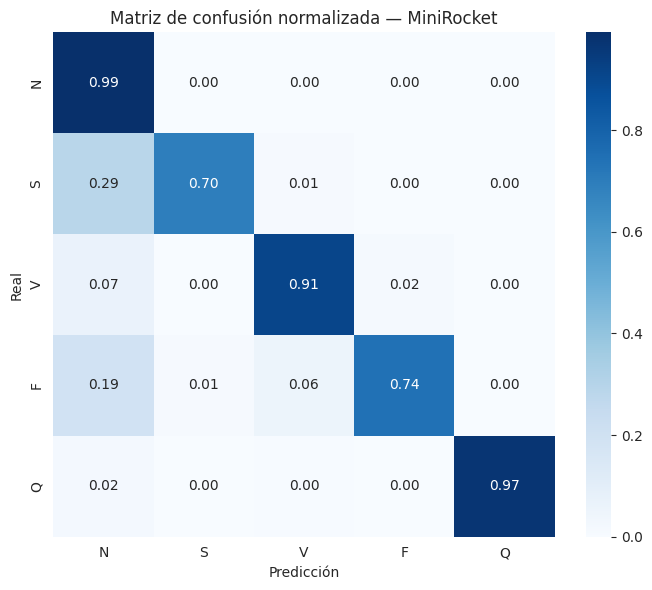

In [28]:
minirocket.fit(X_tr_3d, y_tr)

# Predicciones sobre validación y test
y_pred_rk_val  = minirocket.predict(X_val_3d)
y_proba_rk_val = minirocket.predict_proba(X_val_3d)

y_pred_rk_test = minirocket.predict(X_test_3d)
y_proba_rk_test = minirocket.predict_proba(X_test_3d)

# Evaluación sobre validación
print("\n--- Resultados en VALIDACIÓN ---")
_ = evaluate_model(y_val, y_pred_rk_val, y_proba=y_proba_rk_val, model_name="MiniRocket (val)")

# Evaluación sobre test
print("\n--- Resultados en TEST ---")
results["MiniRocket"] = evaluate_model(y_test, y_pred_rk_test, y_proba=y_proba_rk_test, model_name="MiniRocket (test)")

# Matriz de confusión sobre test
plot_confusion_matrix(y_test, y_pred_rk_test, "MiniRocket", normalize=True)


MiniROCKET supera al Random Forest en todas las métricas, especialmente en las clases minoritarias. MiniROCKET extrae patrones convolucionales (forma temporal, picos, simetrías) que es justo lo que diferencia cada una de las clases.

  ### 7.5 Modelo 1 - CNN 1D (sin class weights)

Una convolución 1D es un filtro pequeño (ej. de 5 puntos) que se desliza por la señal de 187 puntos detectando patrones locales: un pico, una pendiente,una caída. Cada filtro aprende a detectar un patrón distinto.
Apilando varias capas convolucionales, la red aprende patrones cada vez más complejos:

* Capa 1: patrones locales muy básicos (subidas, bajadas, picos puntuales)
* Capa 2: combinaciones de los patrones anteriores (ej. "pico seguido de bajada lenta")
* Capa 3: patrones aún más complejos (formas globales del latido)




In [29]:
class SimpleCNN1D(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()

        # Bloque 1: Conv → BN → ReLU → Pool
        self.conv1 = nn.Conv1d(1, 32, 5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)

        # Bloque 2: Conv → BN → ReLU → Pool
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        # Bloque 3: Conv → BN → ReLU (sin pool)
        self.conv3 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)

        # Pool global y clasificador final
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, n_classes)

        # Activación (la podemos reutilizar)
        self.relu = nn.ReLU()

        # Pooling (reutilizable para todas las capas)
        self.pool = nn.MaxPool1d(2)

    def forward(self, x):
        # Bloque 1
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        # Bloque 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        # Bloque 3
        x = self.relu(self.bn3(self.conv3(x)))
        # Pool global y clasificador
        x = self.gap(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

Antes de entrenar hago un forward pass de prueba para ver si la arquitectura funciona correctamente.

In [30]:
# Instanciar y mover a GPU
model = SimpleCNN1D(n_classes=5).to(device)

# Batch sintético con la misma forma que los datos reales
dummy_input = torch.randn(16, 1, 187).to(device)

# Forward pass
output = model(dummy_input)

print(f"Forma de la entrada:  {dummy_input.shape}")
print(f"Forma de la salida:   {output.shape}")
print(f"\nTotal de parámetros: {sum(p.numel() for p in model.parameters()):,}")

Forma de la entrada:  torch.Size([16, 1, 187])
Forma de la salida:   torch.Size([16, 5])

Total de parámetros: 36,293


In [31]:
# Instanciar el modelo (uno nuevo, sin pesos previos)
model_cnn = SimpleCNN1D(n_classes=5).to(device)

# Crear el Learner
learn_cnn = Learner(
    dls,
    model_cnn,
    loss_func=nn.CrossEntropyLoss(),    # SIN class weights
    opt_func=Adam,
    metrics=metrics_list                # accuracy, f1_macro, f1_weighted
)

In [32]:
print(type(learn_cnn))

<class 'fastai.learner.Learner'>


SuggestedLRs(valley=0.0014454397605732083)

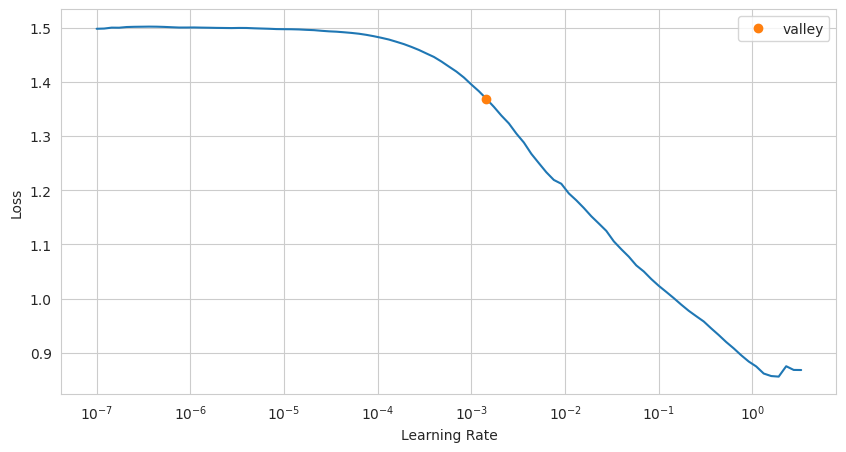

In [33]:
from fastai.callback.schedule import lr_find
learn_cnn.lr_find()

In [34]:
# Entrenamiento del modelo
learn_cnn.fit_one_cycle(20, lr_max=1e-3)

[0, 0.7063526511192322, 0.6174437403678894, 0.8276991248130798, 0.18163451478679277, 0.7499407786679141, '00:03']
[1, 0.3755005896091461, 0.3317142724990845, 0.8945484757423401, 0.4136497434470573, 0.8595476040245512, '00:04']
[2, 0.2050301879644394, 0.2066873461008072, 0.9513476490974426, 0.6581556755309265, 0.9453868650285212, '00:05']
[3, 0.160952627658844, 0.15186505019664764, 0.9550023078918457, 0.6499957070438727, 0.9473409258613544, '00:03']
[4, 0.14879383146762848, 0.1405419260263443, 0.9582762122154236, 0.71048928539125, 0.9525527677510002, '00:03']
[5, 0.13070999085903168, 0.2545217275619507, 0.9059692621231079, 0.7078419992373685, 0.9134279365872522, '00:03']
[6, 0.11905720829963684, 0.18679779767990112, 0.9450281858444214, 0.7661608528034363, 0.9435057192082223, '00:03']
[7, 0.11256711930036545, 0.11926567554473877, 0.9697731137275696, 0.855983975070268, 0.9690490653538331, '00:03']
[8, 0.10140495002269745, 0.10165993869304657, 0.971904993057251, 0.8396921760466153, 0.96984


  CNN sin pesos (test)
  Accuracy        : 0.9765
  F1-weighted     : 0.9752
  F1-macro     : 0.8740
  AUC weighted    : 0.9884
                      precision    recall  f1-score   support

          N (Normal)       0.98      0.99      0.99     18118
S (Supraventricular)       0.86      0.60      0.71       556
     V (Ventricular)       0.95      0.93      0.94      1448
          F (Fusión)       0.83      0.69      0.75       162
     Q (Desconocido)       0.99      0.98      0.99      1608

            accuracy                           0.98     21892
           macro avg       0.92      0.84      0.87     21892
        weighted avg       0.98      0.98      0.98     21892



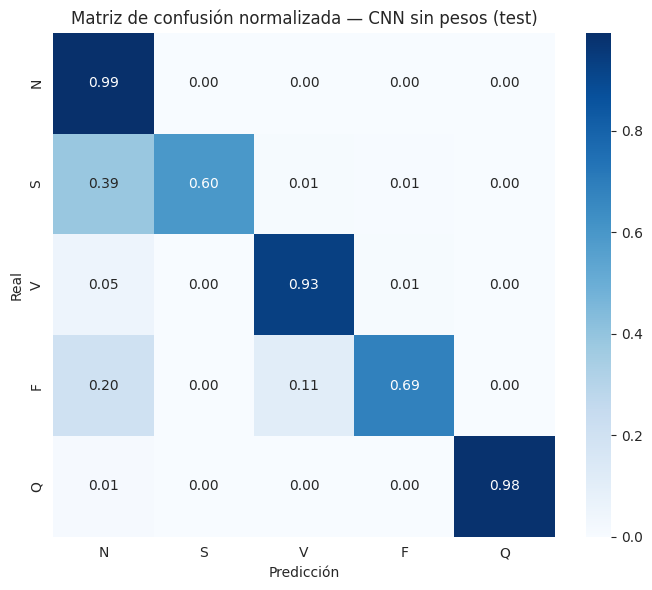

In [35]:
results["CNN sin pesos"] = evaluate_learner(
    learn_cnn, X_test_tensor, y_test_tensor, model_name="CNN sin pesos (test)"
)

La clase S es la que peor se clasifica con un acierto del 59% unicamente, además el 39% las clasifica como normales. La otra categoria que no se clasifica correctamente es la F con un 70% de acierto. Además, el 30% de fusiones se pierden repartidas entre N y V. Las clases mayoritarias N y Q son casi perfectas.

  ### 7.5 Modelo 2 - CNN 1D (con class weights)

In [36]:
# Modelo nuevo
model_cnn_w = SimpleCNN1D(n_classes=5).to(device)

# Learner con CrossEntropyLoss con class weights
learn_cnn_w = Learner(
    dls,
    model_cnn_w,
    loss_func=nn.CrossEntropyLoss(weight=class_weights_tensor),  # añado el class weight
    opt_func=Adam,
    metrics=metrics_list
)

In [37]:
learn_cnn_w.fit_one_cycle(20, lr_max=1e-3)

epoch,train_loss,valid_loss,accuracy,f1_macro,f1_weighted,time
0,1.287830,1.209987,0.297168,0.344722,0.373340,00:04
1,0.821982,0.744969,0.560073,0.484045,0.666172,00:03
2,0.563664,0.620791,0.303030,0.389039,0.369722,00:03
3,0.461102,0.513888,0.817268,0.629276,0.860641,00:03
4,0.419237,0.522389,0.382290,0.420786,0.459370,00:04
5,0.364130,0.783016,0.744556,0.515743,0.785244,00:03
6,0.353169,0.516403,0.537612,0.496057,0.641476,00:03
7,0.312058,0.376948,0.646718,0.558100,0.734255,00:03
8,0.310662,0.315869,0.814832,0.618345,0.853629,00:04
9,0.290823,0.481325,0.687529,0.503931,0.734383,00:03



  CNN con pesos (test)
  Accuracy        : 0.8941
  F1-weighted     : 0.9161
  F1-macro     : 0.7058
  AUC weighted    : 0.9862
                      precision    recall  f1-score   support

          N (Normal)       0.99      0.89      0.94     18118
S (Supraventricular)       0.25      0.80      0.39       556
     V (Ventricular)       0.84      0.94      0.88      1448
          F (Fusión)       0.22      0.92      0.36       162
     Q (Desconocido)       0.95      0.98      0.96      1608

            accuracy                           0.89     21892
           macro avg       0.65      0.91      0.71     21892
        weighted avg       0.95      0.89      0.92     21892



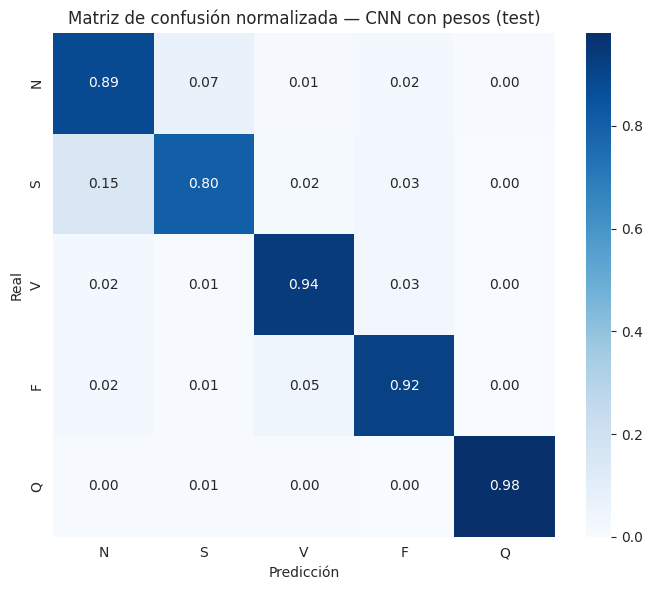

In [38]:
results["CNN con pesos"] = evaluate_learner(
    learn_cnn_w, X_test_tensor, y_test_tensor, model_name="CNN con pesos (test)"
)

El f1-macro baja con el ajuste de pesos. Sin pesos el f1-macro es de 0.87 y con pesos de 0.71. En las clases minoritarias se gana acierto sin embargo en las mayoritarias como la normal se pierde. Con este modeli se ha mejorado el recall de las clases S y F(proporción de clase real que se identifica correctamente) tal y como se puede ver en la matriz de confusión. Al ser los pesos tan agresivos, el modelo aprende que es mucho más caro equivocarse no detectando una F que confundir una N con una F.
Los class weights agresivos dan trade-off precision/recall que conviene considerar caso por caso.

Sin pesos el modelo es más conservador y con pesos es más agresivo. En este caso de diagnostico médico, asumes falsos positivos a cambio de no perderte ninguna arritmia, es decir, CNN con pesos sería mejor a pesar del F1-macro bajo.

  ### 7.6 Modelo 3 - ResNet 1D



In [39]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Las 3 convoluciones con kernels 8, 5, 3
        self.conv1 = nn.Conv1d(in_channels, out_channels, 7, padding=3)   # 1 -> 64 canales
        self.bn1   = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, 5, padding=2)  # 64 -> 64 canales
        self.bn2   = nn.BatchNorm1d(out_channels)

        self.conv3 = nn.Conv1d(out_channels, out_channels, 3, padding=1) # 64 -> 64 canales
        self.bn3   = nn.BatchNorm1d(out_channels)

        # Shortcut: si los canales cambian, usar Conv1d(k=1) para ajustar
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        identity = self.shortcut(x)   # rama paralela

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        out = out + identity              # suma residual
        out = self.relu(out)              # ReLU final
        return out

In [40]:
class ResNet1D(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()

        # Tres bloques residuales
        self.block1 = ResidualBlock(in_channels=1,   out_channels=64)
        self.block2 = ResidualBlock(in_channels=64,  out_channels=128)
        self.block3 = ResidualBlock(in_channels=128, out_channels=128)

        # Pool global y clasificador (igual que en SimpleCNN1D)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc  = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.gap(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

In [41]:
# Forward pass de prueba

# Instanciar y mover a GPU
model_resnet = ResNet1D(n_classes=5).to(device)

# Batch sintético
dummy_input = torch.randn(16, 1, 187).to(device)

# Forward pass
output = model_resnet(dummy_input)

print(f"Forma de la entrada:  {dummy_input.shape}")
print(f"Forma de la salida:   {output.shape}")
print(f"\nTotal de parámetros: {sum(p.numel() for p in model_resnet.parameters()):,}")

Forma de la entrada:  torch.Size([16, 1, 187])
Forma de la salida:   torch.Size([16, 5])

Total de parámetros: 479,749


In [42]:
# Modelo nuevo
model_resnet = ResNet1D(n_classes=5).to(device)

# Learner SIN class weights
learn_resnet = Learner(
    dls,
    model_resnet,
    loss_func=nn.CrossEntropyLoss(),
    opt_func=Adam,
    metrics=metrics_list
)

<div></div>

SuggestedLRs(valley=0.0012022644514217973)

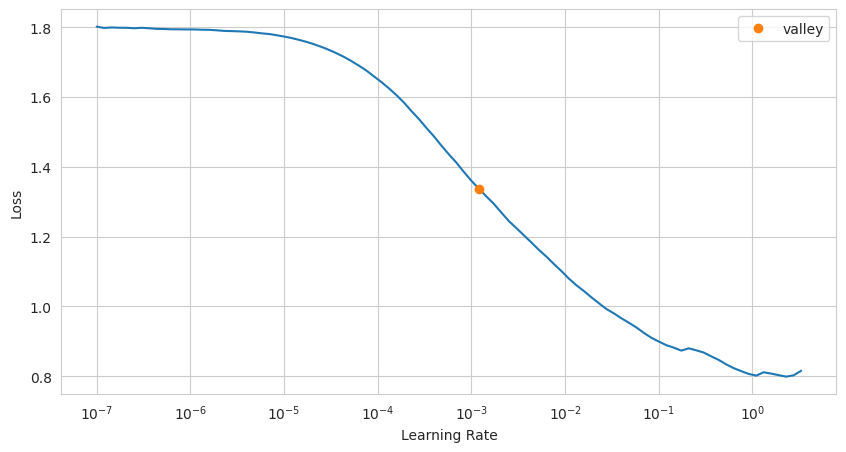

In [43]:
learn_resnet.lr_find()

In [44]:
learn_resnet.fit_one_cycle(20, lr_max=1e-3)

epoch,train_loss,valid_loss,accuracy,f1_macro,f1_weighted,time
0,0.294891,0.286316,0.945942,0.636632,0.938316,00:19
1,0.150806,0.192983,0.958809,0.711333,0.955494,00:19
2,0.120943,0.197548,0.939242,0.719728,0.932928,00:20
3,0.105476,0.160564,0.953251,0.837909,0.953937,00:19
4,0.097914,0.108338,0.968783,0.845221,0.967172,00:19
5,0.084222,0.118485,0.966804,0.869923,0.967844,00:19
6,0.081229,0.088155,0.977844,0.900709,0.977451,00:19
7,0.073047,0.069904,0.981118,0.905073,0.980417,00:19
8,0.063065,0.086239,0.976245,0.854958,0.976500,00:19
9,0.057034,0.071417,0.979900,0.903300,0.979827,00:19



  ResNet 1D sin pesos (test)
  Accuracy        : 0.9867
  F1-weighted     : 0.9863
  F1-macro     : 0.9247
  AUC weighted    : 0.9956
                      precision    recall  f1-score   support

          N (Normal)       0.99      1.00      0.99     18118
S (Supraventricular)       0.92      0.76      0.83       556
     V (Ventricular)       0.97      0.96      0.97      1448
          F (Fusión)       0.87      0.81      0.84       162
     Q (Desconocido)       1.00      0.99      0.99      1608

            accuracy                           0.99     21892
           macro avg       0.95      0.90      0.92     21892
        weighted avg       0.99      0.99      0.99     21892



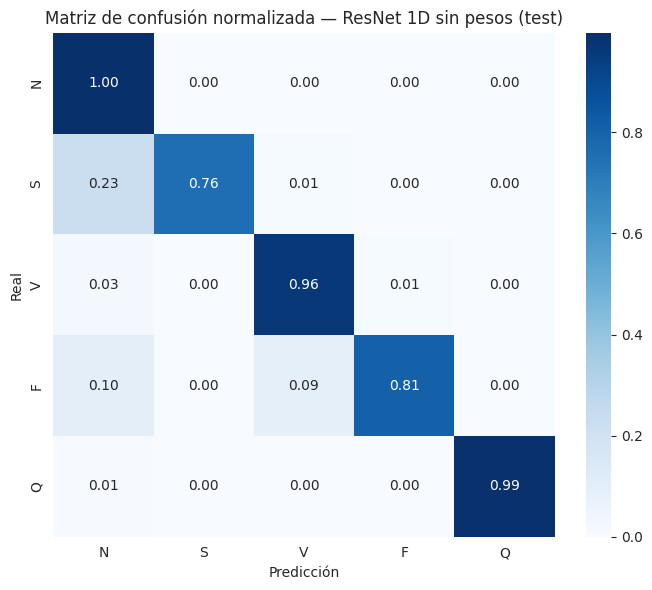

In [45]:
results["ResNet 1D sin pesos"] = evaluate_learner(
    learn_resnet, X_test_tensor, y_test_tensor, model_name="ResNet 1D sin pesos (test)"
)

ResNet supera tanto en F1-macro como en F1-weighted a todos los anteriores modelos. Sin necesidad de class weights consigue un recall de 0.76 para S y de 0.79 para F superando al CNN 1D sin class weight. Esto significa que el modelo tiene más capacidad de detctar patrones gracias a las conexiones residuales sin necesidad de class weights. En comparación con la CNN con pesos, las clases minoritarias las clasifica peor. Sim emabrgo se puede decir que la ResNet sin pesos logra un equilibrio mucho mejor.

Dado que en el contexto clinico es importante detectar las clases minoritarias, que son suceptibles de patología, vamos a probar el modelo con class weight tambien como se ha hehco en la CNN.

### 7.7 ResNet (con class weight)

In [46]:
# Modelo nuevo
model_resnet_w = ResNet1D(n_classes=5).to(device)

# Learner con class weights
learn_resnet_w = Learner(
    dls,
    model_resnet_w,
    loss_func=nn.CrossEntropyLoss(weight=class_weights_tensor),
    opt_func=Adam,
    metrics=metrics_list
)

In [47]:
learn_resnet_w.fit_one_cycle(20, lr_max=1e-3)

epoch,train_loss,valid_loss,accuracy,f1_macro,f1_weighted,time
0,0.610408,0.502056,0.816811,0.605168,0.850711,00:19
1,0.410336,0.609460,0.825263,0.603608,0.871187,00:19
2,0.381025,1.229764,0.198416,0.351731,0.263390,00:19
3,0.367592,0.365449,0.821075,0.631580,0.871199,00:19
4,0.311238,0.425091,0.655855,0.519336,0.722112,00:19
5,0.280442,0.418974,0.914268,0.721238,0.926418,00:19
6,0.252225,0.323704,0.904599,0.780137,0.925912,00:19
7,0.236744,0.226276,0.855185,0.707347,0.894055,00:19
8,0.215289,0.238480,0.875742,0.688271,0.906372,00:19
9,0.187583,0.229828,0.894777,0.740911,0.912191,00:19



  ResNet 1D - con pesos (test)
  Accuracy        : 0.9588
  F1-weighted     : 0.9633
  F1-macro     : 0.8368
  AUC weighted    : 0.9938
                      precision    recall  f1-score   support

          N (Normal)       1.00      0.96      0.98     18118
S (Supraventricular)       0.49      0.88      0.63       556
     V (Ventricular)       0.91      0.97      0.94      1448
          F (Fusión)       0.51      0.93      0.66       162
     Q (Desconocido)       0.98      0.99      0.99      1608

            accuracy                           0.96     21892
           macro avg       0.78      0.94      0.84     21892
        weighted avg       0.97      0.96      0.96     21892



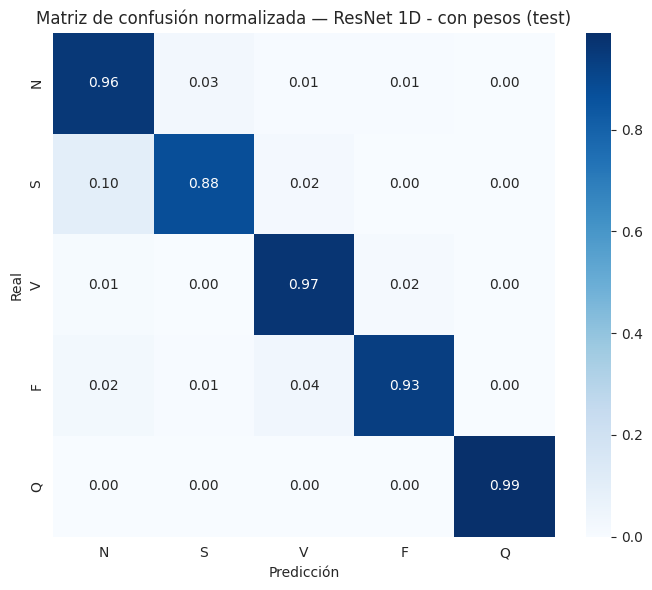

In [48]:
results["ResNet 1D con pesos"] = evaluate_learner(
    learn_resnet_w, X_test_tensor, y_test_tensor, model_name="ResNet 1D - con pesos (test)"
)

A pesar de obtener peor F1-macro que sin class weight (0.84 frente a 0.92) ResNet con pesos generaliza mejor.

### 7.7 Modelo 4 - InceptionTime

In [49]:
class InceptionModule(nn.Module):
    def __init__(self, in_channels, n_filters=32, kernel_sizes=[10, 20, 40], bottleneck_channels=32):
        super().__init__()

        # Bottleneck inicial: Conv 1x1 que reduce canales
        self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, kernel_size=1, bias=False)

        # 3 convoluciones en paralelo con kernel_sizes distintos
        self.convs = nn.ModuleList([
            nn.Conv1d(bottleneck_channels, n_filters, kernel_size=k, padding='same', bias=False) for k in kernel_sizes
        ])

        # Rama paralela: MaxPool + Conv 1x1
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(bottleneck_channels, n_filters, kernel_size=1, bias=False))


        # BatchNorm sobre la concatenación
        self.bn = nn.BatchNorm1d(n_filters * (len(kernel_sizes) + 1))

        self.relu = nn.ReLU()

    def forward(self, x):
        # 1. Aplicar bottleneck a la entrada
        x_bottleneck = self.bottleneck(x)

        # 2. Aplicar las 3 convoluciones en paralelo sobre x_bottleneck
        conv_outputs = [conv(x_bottleneck) for conv in self.convs]

        # 3. Rama paralela: maxpool sobre x_bottleneck, luego conv 1x1
        pool_output = self.maxpool_conv(x_bottleneck)

        # 4. Concatenar las 4 salidas por dimensión de canales
        out = torch.cat([pool_output] + conv_outputs, dim=1)

        # 5. BatchNorm + ReLU
        out = self.relu(self.bn(out))
        return out


In [50]:
class InceptionTime(nn.Module):
    def __init__(self, n_classes=5, in_channels=1, n_filters=32, kernel_sizes=[10, 20, 40], bottleneck_channels=32):
        super().__init__()


        out_channels = n_filters * (len(kernel_sizes) + 1) # 128

        # 6 módulos Inception
        # IMPORTANTE: el primero recibe in_channels (= 1), los demás reciben out_channels
        # Pista: usa nn.Sequential o nn.ModuleList con un loop
        self.blocks = nn.Sequential(
            InceptionModule(in_channels, n_filters, kernel_sizes, bottleneck_channels),
            *[InceptionModule(out_channels, n_filters, kernel_sizes, bottleneck_channels) for _ in range(5)]
            ) # *[lista] desempaqueta la lista en argumentos sueltos
        # Pool global y clasificador final
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc  = nn.Linear(out_channels, n_classes)

    def forward(self, x):
        # 1. Pasar por todos los bloques
        x = self.blocks(x)

        # 2. GAP + squeeze
        x = self.gap(x).squeeze(-1)

        # 3. Clasificador final
        x = self.fc(x)
        return x


In [51]:
# forward pass de prueba
model_inception = InceptionTime(n_classes=5, in_channels=1).to(device)
dummy = torch.randn(16, 1, 187).to(device)
out = model_inception(dummy)
print(f"Forma de la entrada:  {dummy.shape}")
print(f"Forma de la salida:   {out.shape}")
print(f"Total parámetros: {sum(p.numel() for p in model_inception.parameters()):,}")

Forma de la entrada:  torch.Size([16, 1, 187])
Forma de la salida:   torch.Size([16, 5])
Total parámetros: 458,917


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(


In [52]:
# Modelo nuevo
model_inception = InceptionTime(n_classes=5).to(device)

# Learner SIN class weights
learn_inception = Learner(
    dls,
    model_inception,
    loss_func=nn.CrossEntropyLoss(),
    opt_func=Adam,
    metrics=metrics_list
)

In [53]:
learn_inception.fit_one_cycle(20, lr_max=1e-3)

epoch,train_loss,valid_loss,accuracy,f1_macro,f1_weighted,time
0,0.365025,0.310425,0.946323,0.549775,0.930630,00:22
1,0.144999,0.302463,0.903076,0.469412,0.878256,00:22
2,0.101053,0.147373,0.963377,0.761480,0.959048,00:22
3,0.090347,0.351636,0.876656,0.741674,0.889170,00:22
4,0.076350,0.118690,0.966423,0.853437,0.966249,00:22
5,0.064910,0.294426,0.901325,0.668091,0.915983,00:22
6,0.057019,0.074865,0.979062,0.879468,0.978846,00:22
7,0.052247,0.217747,0.926603,0.767985,0.931798,00:22
8,0.045176,0.054784,0.983706,0.904073,0.983315,00:22
9,0.040629,0.078321,0.980204,0.885835,0.979212,00:22



  InceptionTime - sin pesos (test)
  Accuracy        : 0.9891
  F1-weighted     : 0.9889
  F1-macro     : 0.9372
  AUC weighted    : 0.9969
                      precision    recall  f1-score   support

          N (Normal)       0.99      1.00      0.99     18118
S (Supraventricular)       0.93      0.84      0.88       556
     V (Ventricular)       0.97      0.96      0.97      1448
          F (Fusión)       0.88      0.82      0.85       162
     Q (Desconocido)       1.00      0.99      0.99      1608

            accuracy                           0.99     21892
           macro avg       0.95      0.92      0.94     21892
        weighted avg       0.99      0.99      0.99     21892



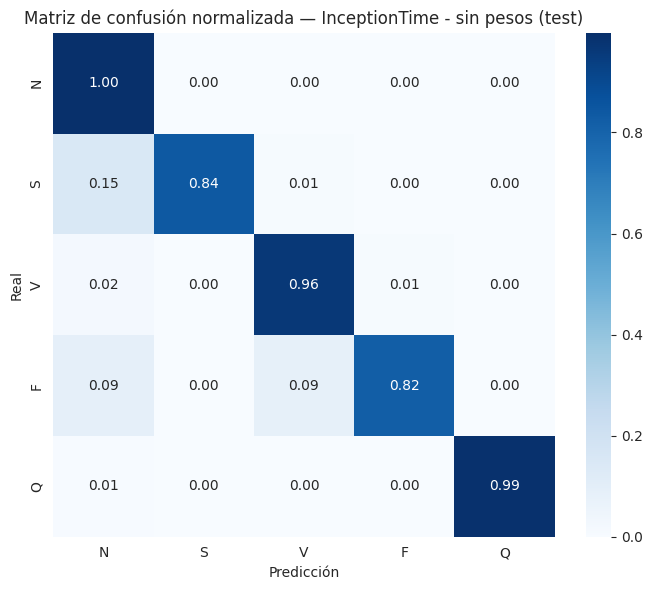

In [54]:
results["InceptionTime sin pesos"] = evaluate_learner(
    learn_inception, X_test_tensor, y_test_tensor, model_name="InceptionTime - sin pesos (test)"
)

### 7.9 InceptionTime con pesos


In [55]:
# Modelo nuevo
model_inception_w = InceptionTime(n_classes=5).to(device)

# Learner con class weights
learn_inception_w = Learner(
    dls,
    model_inception_w,
    loss_func=nn.CrossEntropyLoss(weight=class_weights_tensor),
    opt_func=Adam,
    metrics=metrics_list
)

In [56]:
learn_inception_w.fit_one_cycle(20, lr_max=1e-3)

epoch,train_loss,valid_loss,accuracy,f1_macro,f1_weighted,time
0,0.505443,0.610459,0.625019,0.479859,0.720293,00:22
1,0.384588,0.551364,0.717908,0.611907,0.796036,00:22
2,0.333123,0.406303,0.834399,0.677662,0.863900,00:22
3,0.302731,0.502031,0.932085,0.705665,0.937345,00:22
4,0.293334,0.545707,0.908330,0.758270,0.915790,00:22
5,0.257718,0.404187,0.671616,0.537208,0.739090,00:23
6,0.213280,0.208432,0.923176,0.746434,0.938052,00:22
7,0.227115,0.310158,0.945637,0.814381,0.950820,00:23
8,0.191449,0.257507,0.917999,0.775809,0.929330,00:23
9,0.164573,0.243183,0.935435,0.771478,0.949315,00:22



  InceptionTime - con pesos (test)
  Accuracy        : 0.9783
  F1-weighted     : 0.9794
  F1-macro     : 0.8927
  AUC weighted    : 0.9966
                      precision    recall  f1-score   support

          N (Normal)       1.00      0.98      0.99     18118
S (Supraventricular)       0.70      0.90      0.78       556
     V (Ventricular)       0.95      0.97      0.96      1448
          F (Fusión)       0.63      0.91      0.74       162
     Q (Desconocido)       0.99      0.99      0.99      1608

            accuracy                           0.98     21892
           macro avg       0.85      0.95      0.89     21892
        weighted avg       0.98      0.98      0.98     21892



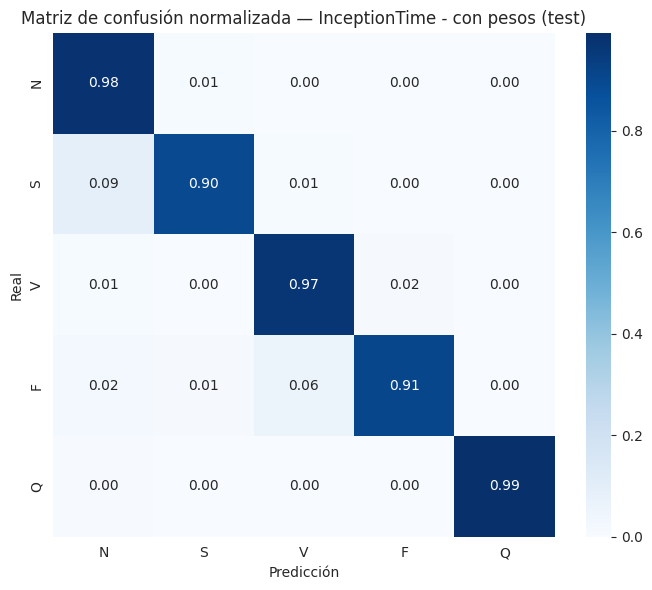

In [57]:
results["InceptionTime con pesos"] = evaluate_learner(
    learn_inception_w, X_test_tensor, y_test_tensor, model_name="InceptionTime - con pesos (test)"
)

## 8. Comparación final y selección del mejor modelo

### 8.1 Tabla resumen de todos los modelos

In [58]:
# Convertir el dict de resultados a DataFrame
rows = []
for model_name, r in results.items():
    rows.append({
        "Modelo": r["model"],
        "Accuracy": r["accuracy"],
        "F1-weighted": r["f1_weighted"],
        "F1-macro": r["f1_macro"],
        "AUC weighted": r.get("auc_weighted", None),
    })
df_resultados = pd.DataFrame(rows).sort_values("F1-macro", ascending=False).reset_index(drop=True)

# Formatear números a 4 decimales
df_resultados.style.format({
    "Accuracy": "{:.4f}",
    "F1-weighted": "{:.4f}",
    "F1-macro": "{:.4f}",
    "AUC weighted": "{:.4f}"
}).background_gradient(subset=["F1-macro", "F1-weighted"], cmap="Greens")

,Modelo,Accuracy,F1-weighted,F1-macro,AUC weighted
0,InceptionTime - sin pesos (test),0.9891,0.9889,0.9372,0.9969
1,ResNet 1D sin pesos (test),0.9867,0.9863,0.9247,0.9956
2,InceptionTime - con pesos (test),0.9783,0.9794,0.8927,0.9966
3,MiniRocket (test),0.9761,0.9755,0.8825,0.9925
4,CNN sin pesos (test),0.9765,0.9752,0.8740,0.9884
5,Random Forest (test),0.9713,0.9701,0.8542,0.9936
6,ResNet 1D - con pesos (test),0.9588,0.9633,0.8368,0.9938
7,CNN con pesos (test),0.8941,0.9161,0.7058,0.9862
8,Baseline trivial (clase mayoritaria),0.8276,0.7495,0.1811,nan


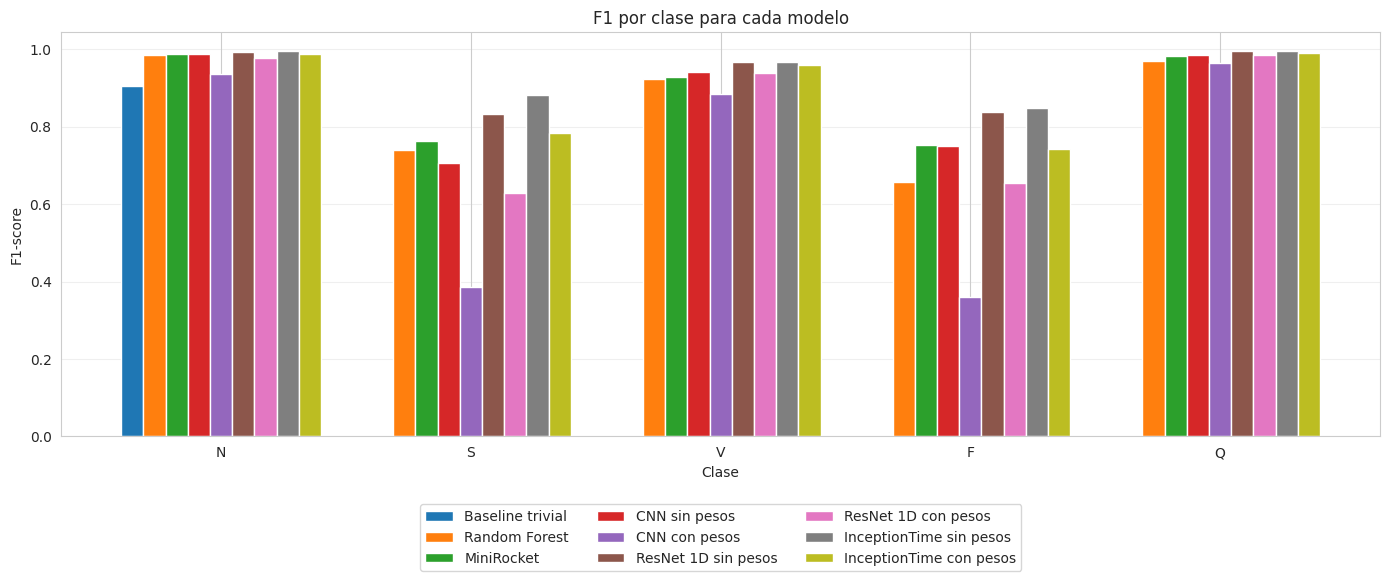

In [60]:
modelos = list(results.keys())
clases = ["N", "S", "V", "F", "Q"]
f1_per_class_matrix = np.array([results[m]["f1_per_class"] for m in modelos])

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(clases))
width = 0.8 / len(modelos)

for i, modelo in enumerate(modelos):
    offset = (i - len(modelos)/2) * width + width/2
    ax.bar(x + offset, f1_per_class_matrix[i], width, label=modelo)

ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.set_xlabel("Clase")
ax.set_ylabel("F1-score")
ax.set_title("F1 por clase para cada modelo")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Tabla F1 por clase
print("\n" + "="*80)
print("F1 POR CLASE (orden N, S, V, F, Q)")
print("="*80)
rows_per_class = []
for name, r in results.items():
    f1pc = r["f1_per_class"]
    rows_per_class.append({
        "Modelo": r["model"],
        "F1_N": f1pc[0],
        "F1_S": f1pc[1],
        "F1_V": f1pc[2],
        "F1_F": f1pc[3],
        "F1_Q": f1pc[4],
    })
df_per_class = pd.DataFrame(rows_per_class)

display(df_per_class.style.format("{:.3f}", subset=["F1_N", "F1_S", "F1_V", "F1_F", "F1_Q"]) \
    .background_gradient(subset=["F1_N", "F1_S", "F1_V", "F1_F", "F1_Q"], cmap="RdYlGn", vmin=0, vmax=1) \
    .set_caption("F1-score por clase para cada modelo"))


F1 POR CLASE (orden N, S, V, F, Q)


,Modelo,F1_N,F1_S,F1_V,F1_F,F1_Q
0,Baseline trivial (clase mayoritaria),0.906,0.000,0.000,0.000,0.000
1,Random Forest (test),0.984,0.738,0.923,0.657,0.969
2,MiniRocket (test),0.987,0.762,0.929,0.752,0.982
3,CNN sin pesos (test),0.987,0.706,0.941,0.750,0.986
4,CNN con pesos (test),0.936,0.385,0.884,0.361,0.964
5,ResNet 1D sin pesos (test),0.993,0.832,0.967,0.837,0.994
6,ResNet 1D - con pesos (test),0.976,0.629,0.938,0.655,0.985
7,InceptionTime - sin pesos (test),0.995,0.882,0.968,0.847,0.995
8,InceptionTime - con pesos (test),0.988,0.784,0.959,0.742,0.990


### 8.2 Análisis comparativo de los modelos

InceptionTime sin pesos consigue el mejor F1-macro (0.937), seguido de cerca por ResNet sin pesos (0.925). Ambos modelos de deep learning mejoran al RF (0.854) en alrededor de 0.08 puntos, una mejora sustancial ya que partiamos de un modelo baseline con un f1-macro bueno y un 0.971 de accuracy. El MiniRocket (f1-macro 0.883) sin ser una red neuronal profunda se sitúa en la cuarta posición superando a las CNN (f1-macro 0.874), lo que evidencia que a veces modelos más sencillos son capaces de dar buenos resultados. 

Las versiones sin pesos obtienen mejores resultados, aunque cuanto más profunda es la red menos se nota el poder de los pesos. En la CNN, que es un red sencilla, la diferencia entre el modelo con pesos y siin pesos es espcialmente notoria. Sin embargo, En el InceptionTime a pesar de exitir un mejor el cambio no es tan pronunciado. En los modelos con pesos se mejora el recall ya que los modelos aciertan mejor las clases minoritarias pero se pierde acierto en el resto de las clases. En estos contextos donde detectar las patologías es importante, tal vez es necesario aplicar modelos con pesos ya que se mejora el acierto en las clases mnortarias que en este caso son las patologicas. 

La clase F y la S son las clases más complicadas de clasificar para todos los modelos. 



### 8.3 Conclusiones

In [61]:
import pickle

# 1. Guardar el dict completo (para recuperar entre sesiones)
with open("/content/drive/MyDrive/SeriesTemp/results.pkl", "wb") as f:
    pickle.dump(results, f)

# 2. Guardar el DataFrame como CSV (para tener una vista tabular fácil de revisar)
df_resultados.to_csv("/content/drive/MyDrive/SeriesTemp/resultados_modelos.csv", index=False)

print("Resultados guardados en Drive")

Resultados guardados en Drive
